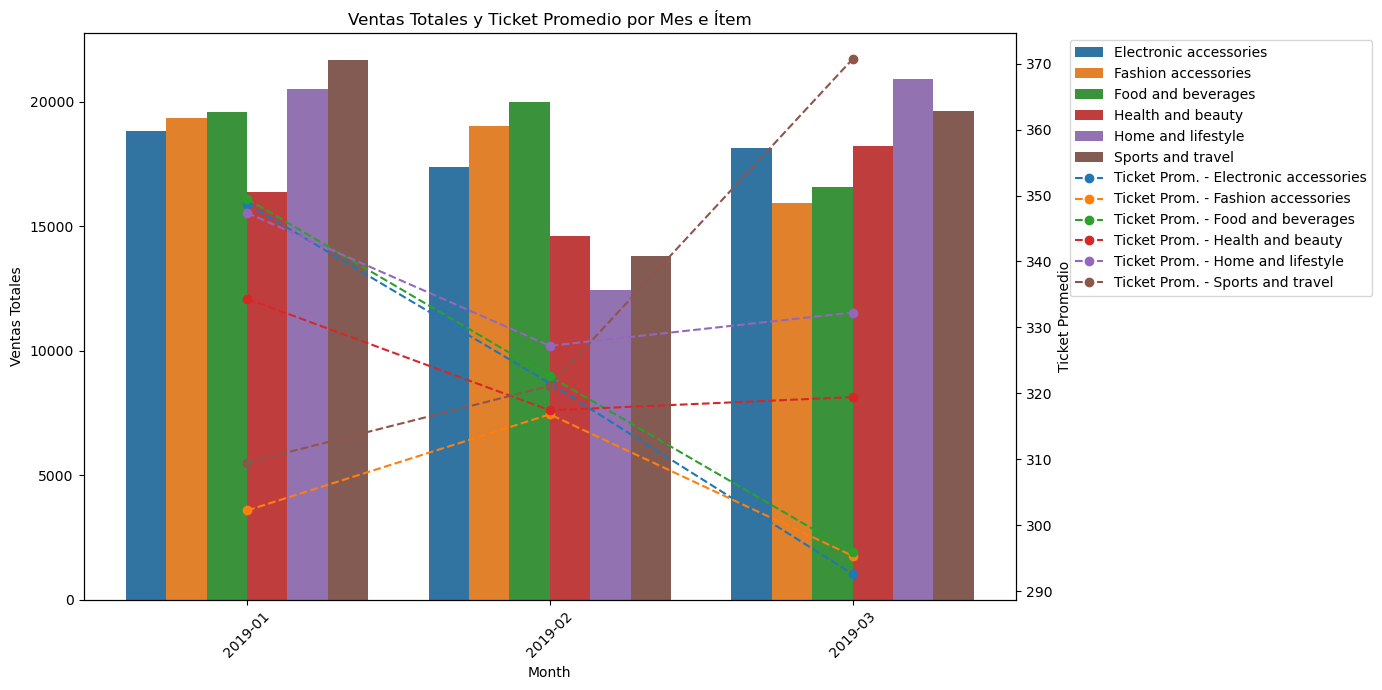

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV
df = pd.read_csv("C:\\Users\\ego_2\\Documents\\Ebac\\Clases\\Python\\Python_avanzado\\supermarket_sales - Sheet1.csv")

# Convertir la columna 'Date' a datetime y crear columna 'Month'
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

# Agrupar por mes e ítem
grouped = df.groupby(['Month', 'Product line']).agg(
    total_sales=('Total', 'sum'),
    avg_invoice=('Total', 'mean')
).reset_index()

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(14, 7))

# Colores para los ítems
palette = sns.color_palette("tab10", n_colors=df['Product line'].nunique())

# Gráfico de barras de ventas totales
sns.barplot(
    data=grouped,
    x='Month', y='total_sales', hue='Product line',
    ax=ax1, palette=palette
)
ax1.set_ylabel('Ventas Totales')
ax1.set_title('Ventas Totales y Ticket Promedio por Mes e Ítem')
ax1.tick_params(axis='x', rotation=45)

# Segundo eje y para ticket promedio
ax2 = ax1.twinx()

# Gráfico de línea para ticket promedio
for i, item in enumerate(grouped['Product line'].unique()):
    item_data = grouped[grouped['Product line'] == item]
    ax2.plot(item_data['Month'].astype(str), item_data['avg_invoice'],
             marker='o', label=f'Ticket Prom. - {item}', color=palette[i], linestyle='--')

ax2.set_ylabel('Ticket Promedio')

# Combinar leyendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


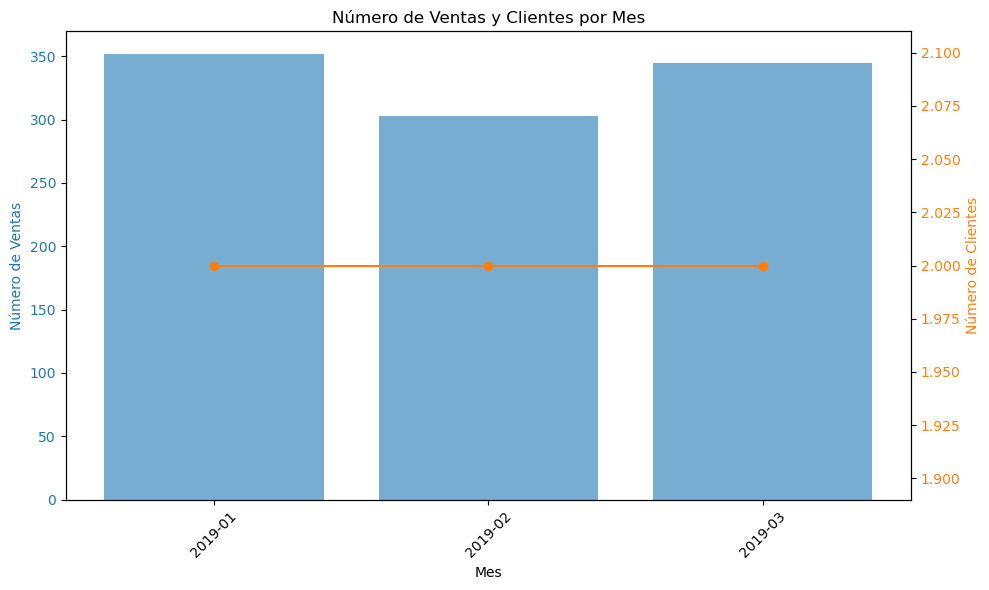

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga de los datos
df = pd.read_csv("C:\\Users\\ego_2\\Documents\\Ebac\\Clases\\Python\\Python_avanzado\\supermarket_sales - Sheet1.csv")

# Asegúrate de convertir la fecha correctamente
df['Date'] = pd.to_datetime(df['Date'])

# Crear nuevas columnas de Año y Mes para agrupar
df['YearMonth'] = df['Date'].dt.to_period('M')

# Total de ventas por mes (contando facturas)
ventas_mensuales = df.groupby('YearMonth').size()

# Número de clientes por mes (contando clientes únicos)
clientes_mensuales = df.groupby('YearMonth')['Customer type'].nunique()

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de barras para número de ventas
color = 'tab:blue'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Número de Ventas', color=color)
ax1.bar(ventas_mensuales.index.astype(str), ventas_mensuales.values, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

# Crear segundo eje para clientes
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Número de Clientes', color=color)
ax2.plot(clientes_mensuales.index.astype(str), clientes_mensuales.values, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

# Títulos y diseño
plt.title('Número de Ventas y Clientes por Mes')
fig.tight_layout()
plt.show()


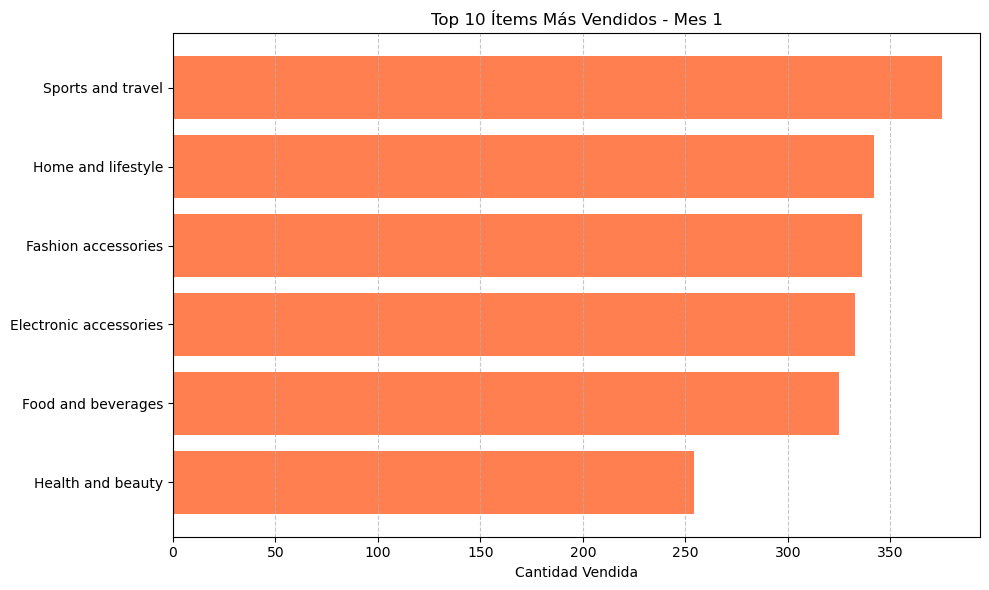

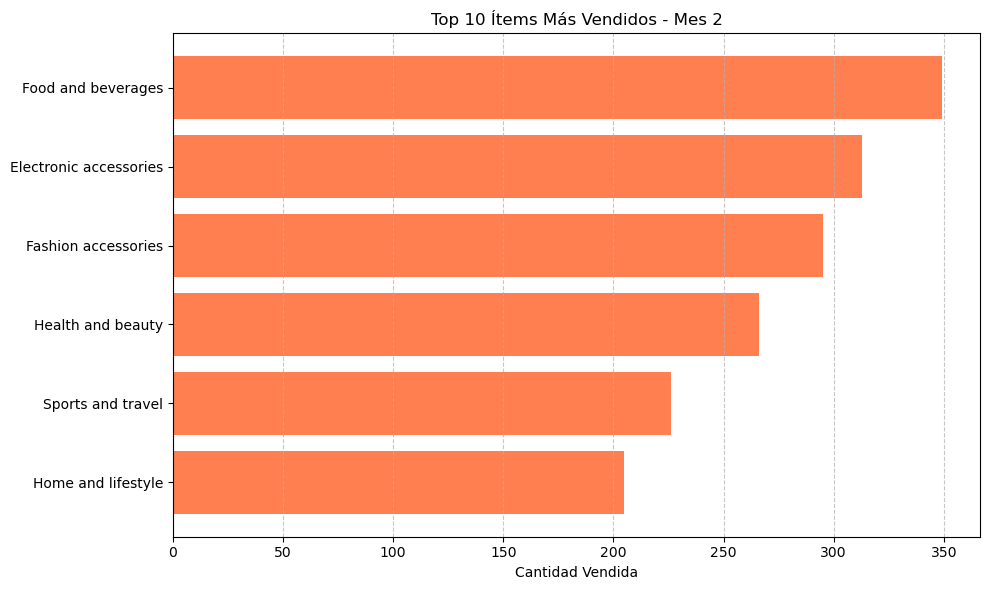

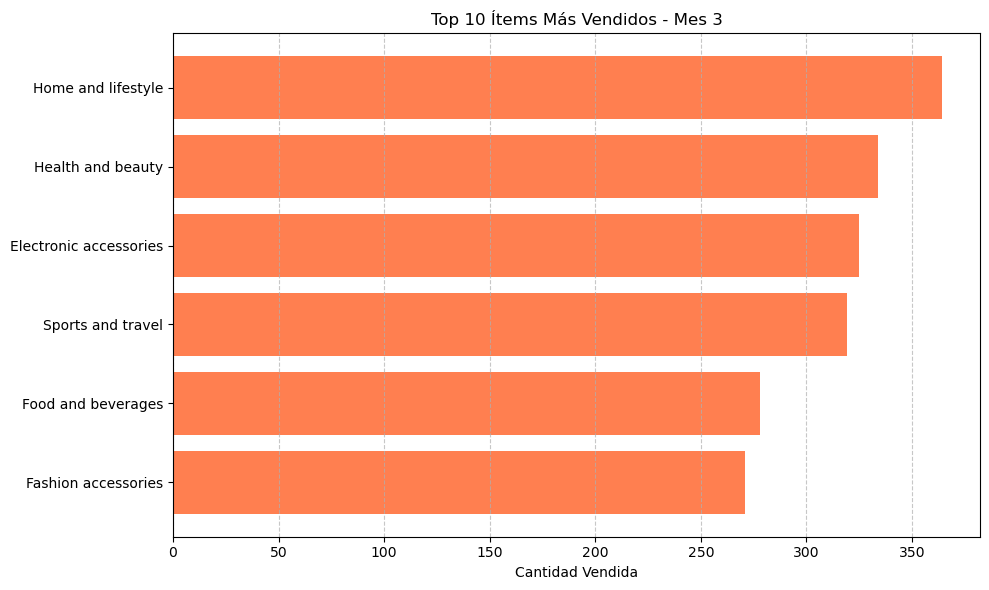

In [7]:
#Wireframe de un reporte ranking de los ítems más vendidos (TOP 10), por mes. Incluir filtro por ítem, mes y criterio.
# Cargar el archivo CSV
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv("C:\\Users\\ego_2\\Documents\\Ebac\\Clases\\Python\\Python_avanzado\\supermarket_sales - Sheet1.csv")

# Convertir la columna Date a formato de fecha
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# Agrupar por Mes y Product line
ventas_por_producto_mes = df.groupby(['Month', 'Product line'])['Quantity'].sum().reset_index()

# Generar un gráfico por cada mes
for mes in sorted(ventas_por_producto_mes['Month'].unique()):
    ventas_mes = ventas_por_producto_mes[ventas_por_producto_mes['Month'] == mes]
    
    # Top 10 productos más vendidos
    top10_productos = ventas_mes.sort_values(by='Quantity', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(top10_productos['Product line'], top10_productos['Quantity'], color='coral')
    plt.xlabel('Cantidad Vendida')
    plt.title(f'Top 10 Ítems Más Vendidos - Mes {mes}')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


Venta total: $322,966.75
Ticket promedio: $322.97


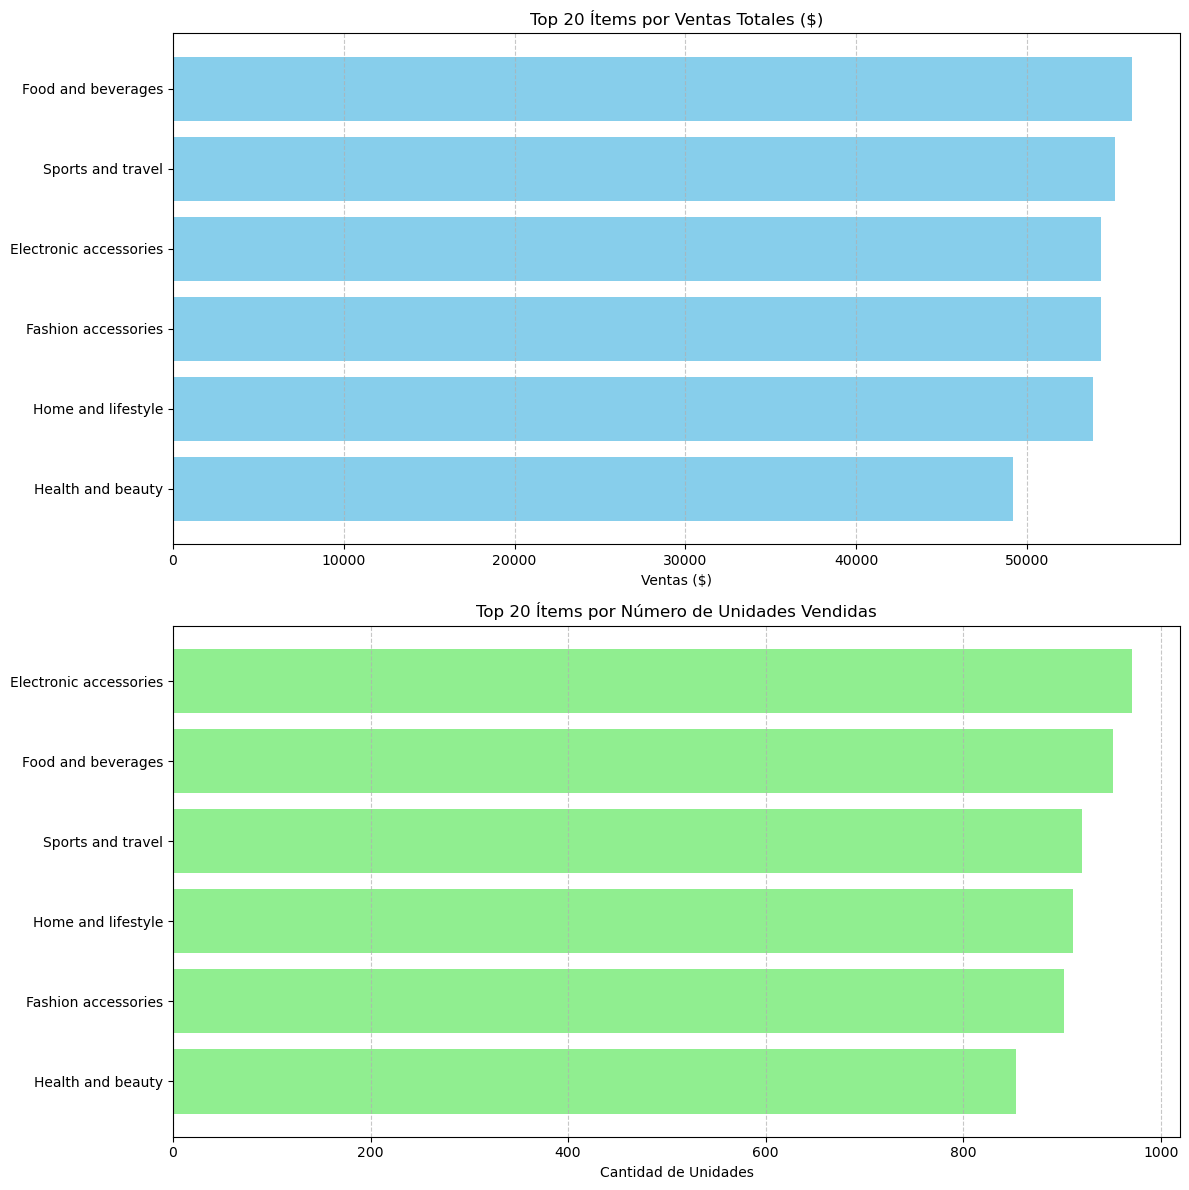

In [8]:
# Convertir Date a formato de fecha y crear columna de Mes
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# 1) KPI: Venta total
venta_total = df['Total'].sum()
print(f'Venta total: ${venta_total:,.2f}')

# 2) KPI: Ticket promedio total
ticket_promedio = df['Total'].mean()
print(f'Ticket promedio: ${ticket_promedio:,.2f}')

# 3) Ranking TOP 20 de Ítems por ventas totales
ventas_por_producto = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).head(20)

# 4) Ranking TOP 20 de Ítems por número de unidades vendidas
ventas_por_cantidad = df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False).head(20)

# Graficar los rankings
fig, axs = plt.subplots(2, 1, figsize=(12, 12))

# Gráfico de ventas totales
axs[0].barh(ventas_por_producto.index, ventas_por_producto.values, color='skyblue')
axs[0].invert_yaxis()
axs[0].set_title('Top 20 Ítems por Ventas Totales ($)')
axs[0].set_xlabel('Ventas ($)')
axs[0].grid(axis='x', linestyle='--', alpha=0.7)

# Gráfico de unidades vendidas
axs[1].barh(ventas_por_cantidad.index, ventas_por_cantidad.values, color='lightgreen')
axs[1].invert_yaxis()
axs[1].set_title('Top 20 Ítems por Número de Unidades Vendidas')
axs[1].set_xlabel('Cantidad de Unidades')
axs[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()